# Agentic RAG with LangGraph – Intelligent Query Router

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This notebook builds an **agentic RAG system** using LangGraph. Unlike simple retrieve-then-generate pipelines, this agent can decide on the fly:
- When to answer from its own knowledge
- When to retrieve from a vector database (PDF documents)
- When to use an external tool (e.g., web search) to get fresh information

This project demonstrates state‑of‑the‑art agentic workflows, a highly sought-after skill for 2026.

## Architecture
1. **Document Ingestion** – Load and chunk PDFs (or use a sample text). Build FAISS index.
2. **Agent Graph** – Define nodes and conditional edges using LangGraph.
3. **Tools** – Provide two tools: `retrieve_from_docs` and `web_search` (via Tavily API).
4. **Routing Logic** – The LLM decides which tool to call based on the user query.
5. **Execution** – The agent runs the graph, outputs final answer with sources.

## Tools Used
- **Groq LLM** (fast inference)
- **FAISS** for vector search
- **Tavily API** for web search (free tier: 1000 requests/month)
- **LangGraph** for agent orchestration

## Files Generated
- `faiss_index_agent/` – Saved FAISS index
- `agent_workflow.png` – Visualisation of the graph (optional)

---

**© 2026 Ibrahim – Agentic RAG system with tool use and routing.**

### Install Dependencies

In [1]:
!pip install -q langgraph langchain langchain-community langchain-groq faiss-cpu sentence-transformers langchain-huggingface langchain-text-splitters tavily-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


###  Imports

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import TypedDict, Annotated, List, Literal
from langgraph.graph import StateGraph, END
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import HumanMessage, AIMessage
from tavily import TavilyClient
from getpass import getpass
import warnings
warnings.filterwarnings('ignore')
print("Imports complete.")

Imports complete.


### Set Up API Keys (Secure)

In [4]:
# Groq API key
groq_key = getpass("Enter your Groq API key: ")
os.environ["GROQ_API_KEY"] = groq_key

# Tavily API key (optional, for web search)
tavily_key = getpass("Enter your Tavily API key (or press Enter to skip web search): ")
if tavily_key:
    os.environ["TAVILY_API_KEY"] = tavily_key
    tavily = TavilyClient(api_key=tavily_key)
    web_search_available = True
else:
    web_search_available = False
    print("Web search disabled. Agent will only use document retrieval.")

llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)
print("LLM ready.")

Enter your Groq API key: ··········
Enter your Tavily API key (or press Enter to skip web search): ··········
LLM ready.


### Create Sample Documents (Fallback if no PDFs)

In [5]:
# For demonstration, create a sample knowledge base
sample_docs = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs.",
    "RAG stands for Retrieval-Augmented Generation. It combines information retrieval with LLMs.",
    "Agentic RAG systems can decide which tools to use at runtime.",
    "FAISS is a library for efficient similarity search and clustering of dense vectors.",
    "Groq provides fast LLM inference using LPU technology.",
    "Tavily is a search engine optimized for LLM agents."
]

# Split into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=20)
chunks = text_splitter.create_documents(sample_docs)

embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks, embedding_model)
print(f"Created vectorstore with {len(chunks)} chunks.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Created vectorstore with 6 chunks.


### Define Tools

In [6]:
@tool
def retrieve_from_docs(query: str) -> str:
    """Search the local document knowledge base for relevant information."""
    docs = vectorstore.similarity_search(query, k=3)
    if not docs:
        return "No relevant information found in documents."
    context = "\n\n".join([doc.page_content for doc in docs])
    return f"Relevant information from documents:\n{context}"

@tool
def web_search(query: str) -> str:
    """Search the web for current or external information."""
    if not web_search_available:
        return "Web search is not configured. Please add Tavily API key."
    try:
        response = tavily.search(query, max_results=2)
        results = response.get('results', [])
        if not results:
            return "No web results found."
        return "\n\n".join([f"Source: {r['url']}\n{r['content']}" for r in results])
    except Exception as e:
        return f"Web search error: {e}"

tools = [retrieve_from_docs, web_search] if web_search_available else [retrieve_from_docs]

### Define Graph State

In [7]:
class AgentState(TypedDict):
    messages: List[Annotated[HumanMessage | AIMessage, "conversation"]]
    next_action: str
    tool_results: str

def decide_next_action(state: AgentState) -> Literal["retrieve", "search", "respond"]:
    """LLM decides what to do based on the user query."""
    last_message = state["messages"][-1].content
    # Simple keyword-based routing for demo
    # For production, you'd use an LLM call with structured output
    if any(word in last_message.lower() for word in ["current", "today", "latest", "news"]):
        return "search"
    elif any(word in last_message.lower() for word in ["document", "according to", "in our knowledge"]):
        return "retrieve"
    else:
        return "respond"

### Define Node Functions

In [8]:
def retrieve_node(state: AgentState):
    """Execute document retrieval."""
    query = state["messages"][-1].content
    result = retrieve_from_docs.invoke({"query": query})
    # Append tool result to tools_results
    state["tool_results"] = result
    return state

def search_node(state: AgentState):
    """Execute web search."""
    query = state["messages"][-1].content
    result = web_search.invoke({"query": query})
    state["tool_results"] = result
    return state

def respond_node(state: AgentState):
    """Generate final answer using tool results if available."""
    context = state.get("tool_results", "")
    query = state["messages"][-1].content
    if context:
        prompt = f"""Answer the question using the context below if helpful. If the context is not relevant, answer based on your own knowledge.

Context:
{context}

Question: {query}

Answer:"""
    else:
        prompt = f"Answer the question directly.\nQuestion: {query}\nAnswer:"

    response = llm.invoke(prompt)
    state["messages"].append(AIMessage(content=response.content))
    return state

###  Build the Graph

In [9]:
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("search", search_node)
workflow.add_node("respond", respond_node)

# Add conditional edges from start
workflow.set_conditional_entry_point(decide_next_action)

# After retrieve or search, always go to respond
workflow.add_edge("retrieve", "respond")
workflow.add_edge("search", "respond")
workflow.add_edge("respond", END)

app = workflow.compile()
print("Agent graph compiled.")

Agent graph compiled.


### Interactive Chat Loop

In [10]:
def run_agent(query):
    state = {
        "messages": [HumanMessage(content=query)],
        "next_action": "",
        "tool_results": ""
    }
    result = app.invoke(state)
    final_answer = result["messages"][-1].content
    print(f"\n Query: {query}")
    print(f" Answer: {final_answer}")
    if result.get("tool_results"):
        print(f"🔧 Used tool result: {result['tool_results'][:150]}...")
    return final_answer

# Test queries
print("\n" + "="*50)
print("Agentic RAG Ready. Type 'exit' to quit.")
print("Try queries like:")
print("  - 'According to the documents, what is LangGraph?'")
print("  - 'What is the current weather in London?' (requires web search)")
print("  - 'Explain RAG with an example.'")
print("="*50)

while True:
    user_q = input("\n Your query: ").strip()
    if user_q.lower() in ["exit", "quit"]:
        break
    if not user_q:
        continue
    run_agent(user_q)


Agentic RAG Ready. Type 'exit' to quit.
Try queries like:
  - 'According to the documents, what is LangGraph?'
  - 'What is the current weather in London?' (requires web search)
  - 'Explain RAG with an example.'

 Your query: What is the current weather in London?

 Query: What is the current weather in London?
 Answer: According to the provided weather data from 'weatherapi.com', the current weather in London is 'Partly cloudy' with a temperature of 59.5°F (15.3°C).
🔧 Used tool result: Source: https://www.weatherapi.com/
{'location': {'name': 'London', 'region': 'City of London, Greater London', 'country': 'United Kingdom', 'lat': 51...

 Your query: quit


### Visualise Graph

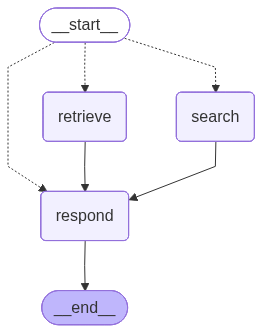

In [11]:
from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print("Graph visualisation requires additional dependencies; skipping.")

### Final Summary

In [12]:
print("\n" + "="*50)
print("Agentic RAG with LangGraph - COMPLETED")
print("Author: Ibrahim")
print("="*50)
print(f" Vectorstore contains {len(chunks)} document chunks.")
print(f" Tools available: document retrieval + {'web search' if web_search_available else 'no web search'}")
print(" Agent can route queries to appropriate tools.")
print(" Full decision graph is compiled and ready.")


Agentic RAG with LangGraph - COMPLETED
Author: Ibrahim
 Vectorstore contains 6 document chunks.
 Tools available: document retrieval + web search
 Agent can route queries to appropriate tools.
 Full decision graph is compiled and ready.
